# PV Forecasting — 5. Data Preparation (Handling Missing Values)

**Purpose:** turn the quality-checked DataFrame into a model-ready dataset by filling in missing values, using domain knowledge where possible (night = 0, power = V×I) and statistical methods for the rest.

**Input:** `../Output/checkpoint_02_quality.pkl`

**Output:** `../Output/final.xlsx` and `../Output/checkpoint_05_final.pkl` — the dataset used for model training

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = "../Output"

In [2]:
df = pd.read_pickle(f"{OUTPUT_DIR}/checkpoint_02_quality.pkl")
df.shape

(5832, 30)

## 6. Data preparation

### 6.1 Handle missing data (when radiation = 0)

In [3]:
# Data before fill NaN values
df.head()

,Timestamp,PV1_Current_A,PV2_Current_A,PV1_Voltage_V,PV2_Voltage_V,PV1_Power_W,PV2_Power_W,PV_Total_Power_W,Solar_Radiation_Wm2,Outdoor_Temp_C,...,PM10_ugm3,PM1_ugm3,Indoor_Temp_C,Indoor_Humidity_pct,Indoor_Pressure_Pa,PV_imputed,hour,month,day_of_year,is_daylight
0,2026-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,10.192,...,18.850,8.167,8.758,75.500,101487.617,0,0,1,1,0
1,2026-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,10.008,...,14.950,6.550,8.487,76.700,101502.483,0,1,1,1,0
2,2026-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,9.875,...,15.017,6.417,8.333,78.700,101543.200,0,2,1,1,0
3,2026-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,9.367,...,17.317,7.567,7.933,81.017,101552.650,0,3,1,1,0
4,2026-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,8.925,...,17.033,8.033,7.430,82.733,101541.567,0,4,1,1,0


In [4]:
# Fill nighttime nulls first
night_mask = df["Solar_Radiation_Wm2"] == 0
power_cols = ["PV1_Power_W", "PV2_Power_W", "PV_Total_Power_W", "PV1_Current_A", "PV2_Current_A", 'PV1_Voltage_V', 'PV2_Voltage_V']
for col in power_cols:
    df.loc[night_mask, col] = df.loc[night_mask, col].fillna(0)

In [5]:
# Data after filling NaN values
df.head()

,Timestamp,PV1_Current_A,PV2_Current_A,PV1_Voltage_V,PV2_Voltage_V,PV1_Power_W,PV2_Power_W,PV_Total_Power_W,Solar_Radiation_Wm2,Outdoor_Temp_C,...,PM10_ugm3,PM1_ugm3,Indoor_Temp_C,Indoor_Humidity_pct,Indoor_Pressure_Pa,PV_imputed,hour,month,day_of_year,is_daylight
0,2026-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.192,...,18.850,8.167,8.758,75.500,101487.617,0,0,1,1,0
1,2026-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.008,...,14.950,6.550,8.487,76.700,101502.483,0,1,1,1,0
2,2026-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.875,...,15.017,6.417,8.333,78.700,101543.200,0,2,1,1,0
3,2026-01-01 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.367,...,17.317,7.567,7.933,81.017,101552.650,0,3,1,1,0
4,2026-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.925,...,17.033,8.033,7.430,82.733,101541.567,0,4,1,1,0


In [6]:
# Save DataFrame to Excel file
df.to_excel(f'{OUTPUT_DIR}/output1.xlsx', index=False)

In [7]:
# Now check what's genuinely missing 
real_missing_pct = df["PV_Total_Power_W"].isna().mean() * 100
print(f"Genuine missing (daytime) %: {real_missing_pct:.1f}%")

Genuine missing (daytime) %: 4.5%


In [8]:
# Find the actual missing blocks — contiguous runs, not just a count
missing = df["PV_Total_Power_W"].isna()
gap_id = (missing != missing.shift()).cumsum()
gaps = (df[missing]
        .groupby(gap_id[missing])
        .agg(start=("Timestamp", "min"), end=("Timestamp", "max"), hours=("Timestamp", "count"))
        .sort_values("hours", ascending=True))
print(gaps)

                               start                 end  hours
PV_Total_Power_W                                               
8                2026-01-07 07:00:00 2026-01-07 07:00:00      1
6                2026-01-04 07:00:00 2026-01-04 07:00:00      1
12               2026-01-20 07:00:00 2026-01-20 07:00:00      1
10               2026-01-16 07:00:00 2026-01-16 07:00:00      1
14               2026-01-26 07:00:00 2026-01-26 07:00:00      1
...                              ...                 ...    ...
62               2026-02-23 13:00:00 2026-02-23 18:00:00      6
66               2026-02-25 06:00:00 2026-02-25 18:00:00     13
64               2026-02-24 06:00:00 2026-02-24 18:00:00     13
128              2026-04-04 05:00:00 2026-04-04 18:00:00     14
130              2026-04-05 05:00:00 2026-04-05 19:00:00     15

[188 rows x 3 columns]


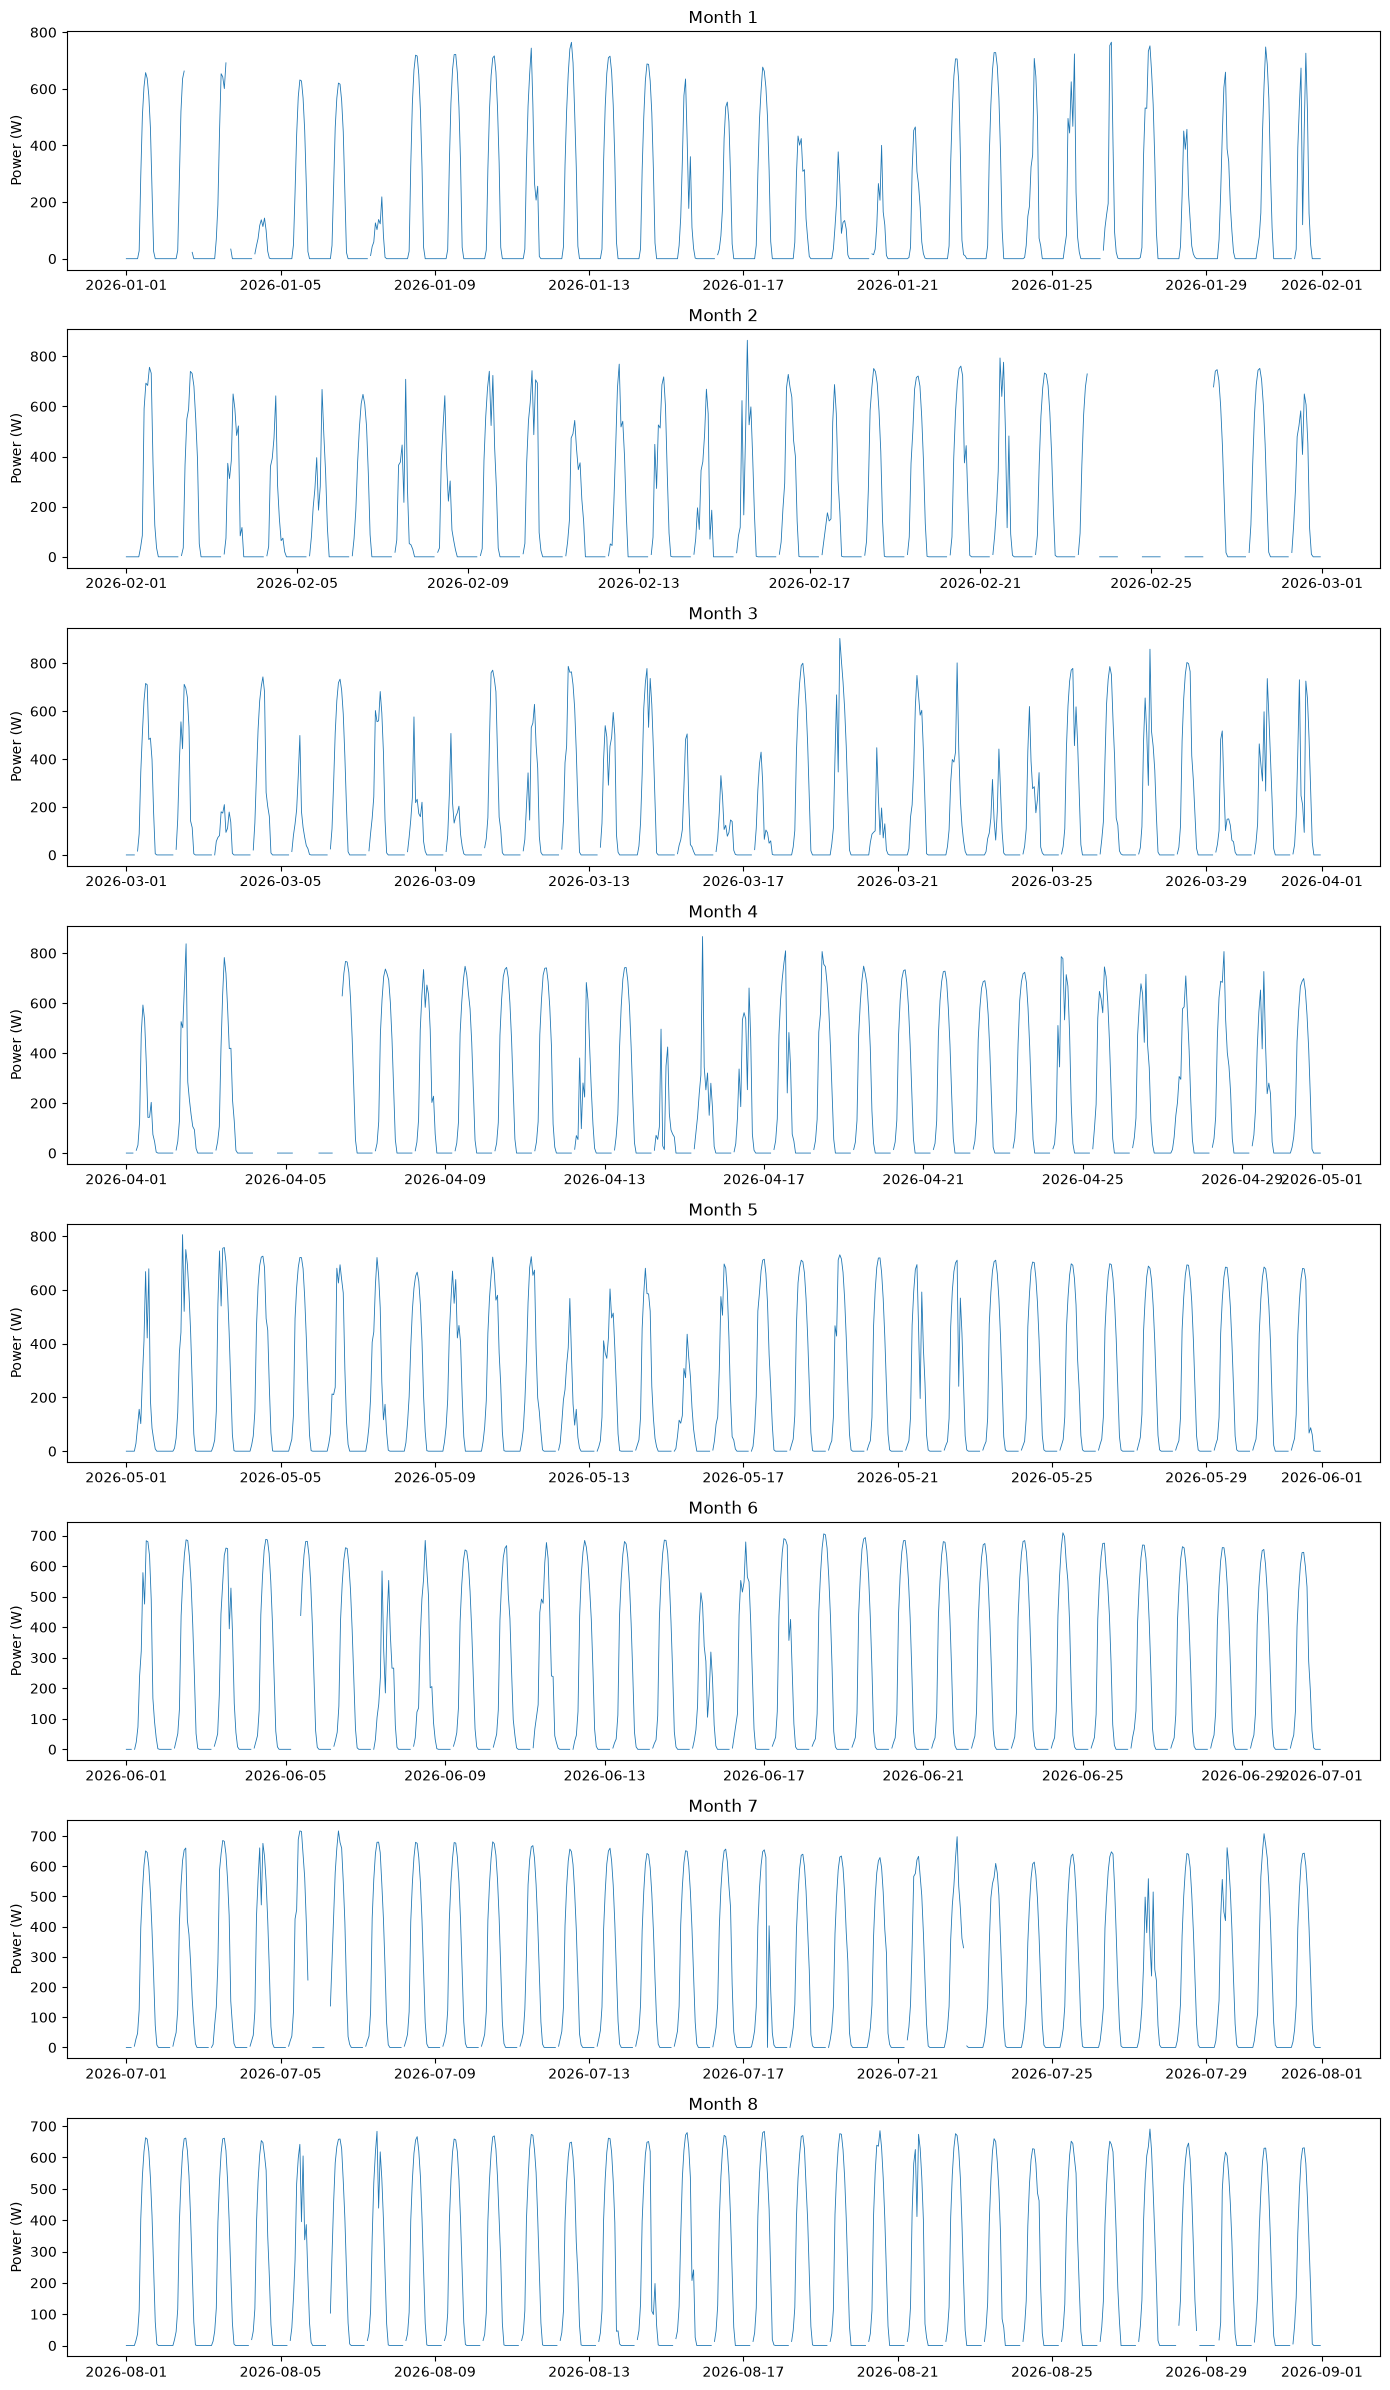

In [9]:
months = sorted(df["month"].unique())
n = len(months)

fig, axes = plt.subplots(n, 1, figsize=(14, 3 * n), sharex=False)
if n == 1:
    axes = [axes]  # keep it iterable when there's only one month

for ax, m in zip(axes, months):
    month_data = df[df["month"] == m]
    ax.plot(month_data["Timestamp"], month_data["PV_Total_Power_W"], linewidth=0.6)
    ax.set_title(f"Month {m}")
    ax.set_ylabel("Power (W)")

plt.tight_layout()
plt.show()

In [10]:
# Find out if PV1_Power_W and PV2_Power_W are null when current and voltage are not null

# PV1
pv1_recoverable = df["PV1_Power_W"].isna() & df["PV1_Current_A"].notna() & df["PV1_Voltage_V"].notna()
print(f"PV1: {pv1_recoverable.sum()} rows where power is missing but current & voltage are available")

# PV2
pv2_recoverable = df["PV2_Power_W"].isna() & df["PV2_Current_A"].notna() & df["PV2_Voltage_V"].notna()
print(f"PV2: {pv2_recoverable.sum()} rows where power is missing but current & voltage are available")

PV1: 15 rows where power is missing but current & voltage are available
PV2: 15 rows where power is missing but current & voltage are available


**Observation:**
- As we can see from the previous block of code, there are rare cases where the power value is missing, while the current and voltage values are available.
- The results show that there are 15 rows for PV1 and PV2 that correspond to this case.

### 6.2 Handling Missing Power Data with Available Voltage and Current

In [11]:
df.loc[pv1_recoverable, "PV1_Power_W"] = (
    df.loc[pv1_recoverable, "PV1_Voltage_V"] * df.loc[pv1_recoverable, "PV1_Current_A"]
)

df.loc[pv2_recoverable, "PV2_Power_W"] = (
    df.loc[pv2_recoverable, "PV2_Voltage_V"] * df.loc[pv2_recoverable, "PV2_Current_A"]
)

# Only fill PV_Total_Power_W where it is missing — do not overwrite existing valid totals
df["PV_Total_Power_W"] = df["PV_Total_Power_W"].fillna(df["PV1_Power_W"] + df["PV2_Power_W"])

In [12]:
# Check using the same code

# PV1
pv1_recoverable = df["PV1_Power_W"].isna() & df["PV1_Current_A"].notna() & df["PV1_Voltage_V"].notna()
print(f"PV1: {pv1_recoverable.sum()} rows where power is missing but current & voltage are available")

# PV2
pv2_recoverable = df["PV2_Power_W"].isna() & df["PV2_Current_A"].notna() & df["PV2_Voltage_V"].notna()
print(f"PV2: {pv2_recoverable.sum()} rows where power is missing but current & voltage are available")

PV1: 0 rows where power is missing but current & voltage are available
PV2: 0 rows where power is missing but current & voltage are available


In [13]:
# Now check what's genuinely missing
real_missing_pct = df["PV_Total_Power_W"].isna().mean() * 100
print(f"Genuine missing (daytime) %: {real_missing_pct:.1f}%")

Genuine missing (daytime) %: 4.3%


In [14]:
# Find the actual missing blocks — contiguous runs, not just a count
missing = df["PV_Total_Power_W"].isna()
gap_id = (missing != missing.shift()).cumsum()
gaps = (df[missing]
        .groupby(gap_id[missing])
        .agg(start=("Timestamp", "min"), end=("Timestamp", "max"), hours=("Timestamp", "count"))
        .sort_values("hours", ascending=True))
print(gaps)

                               start                 end  hours
PV_Total_Power_W                                               
2                2026-01-04 07:00:00 2026-01-04 07:00:00      1
4                2026-01-07 07:00:00 2026-01-07 07:00:00      1
6                2026-01-16 07:00:00 2026-01-16 07:00:00      1
8                2026-01-20 07:00:00 2026-01-20 07:00:00      1
10               2026-01-26 07:00:00 2026-01-26 07:00:00      1
...                              ...                 ...    ...
62               2026-02-26 06:00:00 2026-02-26 10:00:00      5
60               2026-02-25 06:00:00 2026-02-25 18:00:00     13
58               2026-02-24 06:00:00 2026-02-24 18:00:00     13
122              2026-04-04 05:00:00 2026-04-04 18:00:00     14
124              2026-04-05 05:00:00 2026-04-05 19:00:00     15

[183 rows x 3 columns]


In [15]:
# Save DataFrame to Excel file
df.to_excel(f'{OUTPUT_DIR}/output2.xlsx', index=False)

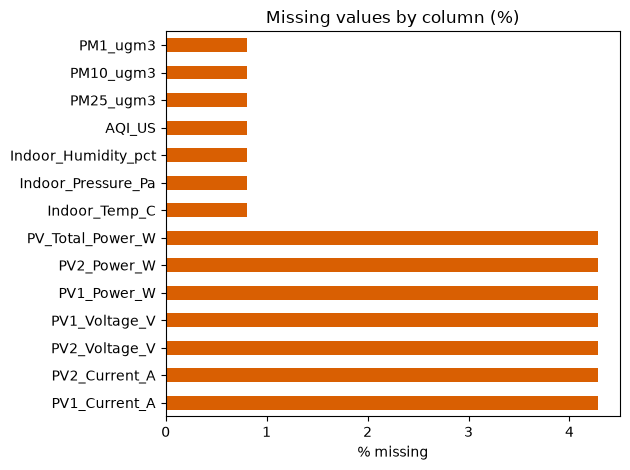

PV1_Current_A          4.286694
PV2_Current_A          4.286694
PV2_Voltage_V          4.286694
PV1_Voltage_V          4.286694
PV1_Power_W            4.286694
PV2_Power_W            4.286694
PV_Total_Power_W       4.286694
Indoor_Temp_C          0.805898
Indoor_Pressure_Pa     0.805898
Indoor_Humidity_pct    0.805898
AQI_US                 0.805898
PM25_ugm3              0.805898
PM10_ugm3              0.805898
PM1_ugm3               0.805898
dtype: float64

In [16]:
missing_pct = df.isna().mean().sort_values(ascending=False) * 100
missing_pct = missing_pct[missing_pct > 0]

if missing_pct.empty:
    print("No missing values remain.")
else:
    missing_pct.plot(kind="barh", color="#d95f02", title="Missing values by column (%)")
    plt.xlabel("% missing")
    plt.tight_layout()
    plt.show()

missing_pct

### 6.3 Handling Missing Values in Environmental & Indoor Sensors

In [17]:
missing_PM1_ugm3 = df.loc[df["PM1_ugm3"].isna()]
missing_PM1_ugm3

,Timestamp,PV1_Current_A,PV2_Current_A,PV1_Voltage_V,PV2_Voltage_V,PV1_Power_W,PV2_Power_W,PV_Total_Power_W,Solar_Radiation_Wm2,Outdoor_Temp_C,...,PM10_ugm3,PM1_ugm3,Indoor_Temp_C,Indoor_Humidity_pct,Indoor_Pressure_Pa,PV_imputed,hour,month,day_of_year,is_daylight
4720,2026-07-16 16:00:00,0.000,0.000,35.40,35.15,237.00,227.00,464.00,675.0,35.9,...,NaN,NaN,NaN,NaN,NaN,0,16,7,197,1
4721,2026-07-16 17:00:00,3.045,2.933,35.20,35.00,107.17,102.65,209.81,495.0,35.3,...,NaN,NaN,NaN,NaN,NaN,1,17,7,197,1
4729,2026-07-17 01:00:00,0.000,0.000,0.00,0.00,0.00,0.00,0.00,0.0,27.2,...,NaN,NaN,NaN,NaN,NaN,0,1,7,198,0
4730,2026-07-17 02:00:00,0.000,0.000,0.00,0.00,0.00,0.00,0.00,0.0,26.5,...,NaN,NaN,NaN,NaN,NaN,0,2,7,198,0
4742,2026-07-17 14:00:00,0.000,0.000,34.90,34.80,321.00,309.00,630.00,915.0,41.1,...,NaN,NaN,NaN,NaN,NaN,0,14,7,198,1
4793,2026-07-19 17:00:00,2.400,2.250,32.05,31.80,146.00,138.00,284.00,478.0,39.3,...,NaN,NaN,NaN,NaN,NaN,0,17,7,200,1
4799,2026-07-19 23:00:00,0.000,0.000,0.00,0.00,0.00,0.00,0.00,0.0,33.0,...,NaN,NaN,NaN,NaN,NaN,0,23,7,200,0
4800,2026-07-20 00:00:00,0.000,0.000,0.00,0.00,0.00,0.00,0.00,0.0,32.2,...,NaN,NaN,NaN,NaN,NaN,0,0,7,201,0
4804,2026-07-20 04:00:00,0.000,0.000,0.00,0.00,0.00,0.00,0.00,0.0,29.9,...,NaN,NaN,NaN,NaN,NaN,0,4,7,201,0
4817,2026-07-20 17:00:00,0.000,0.000,35.00,34.80,161.00,153.00,314.00,482.0,40.0,...,NaN,NaN,NaN,NaN,NaN,0,17,7,201,1


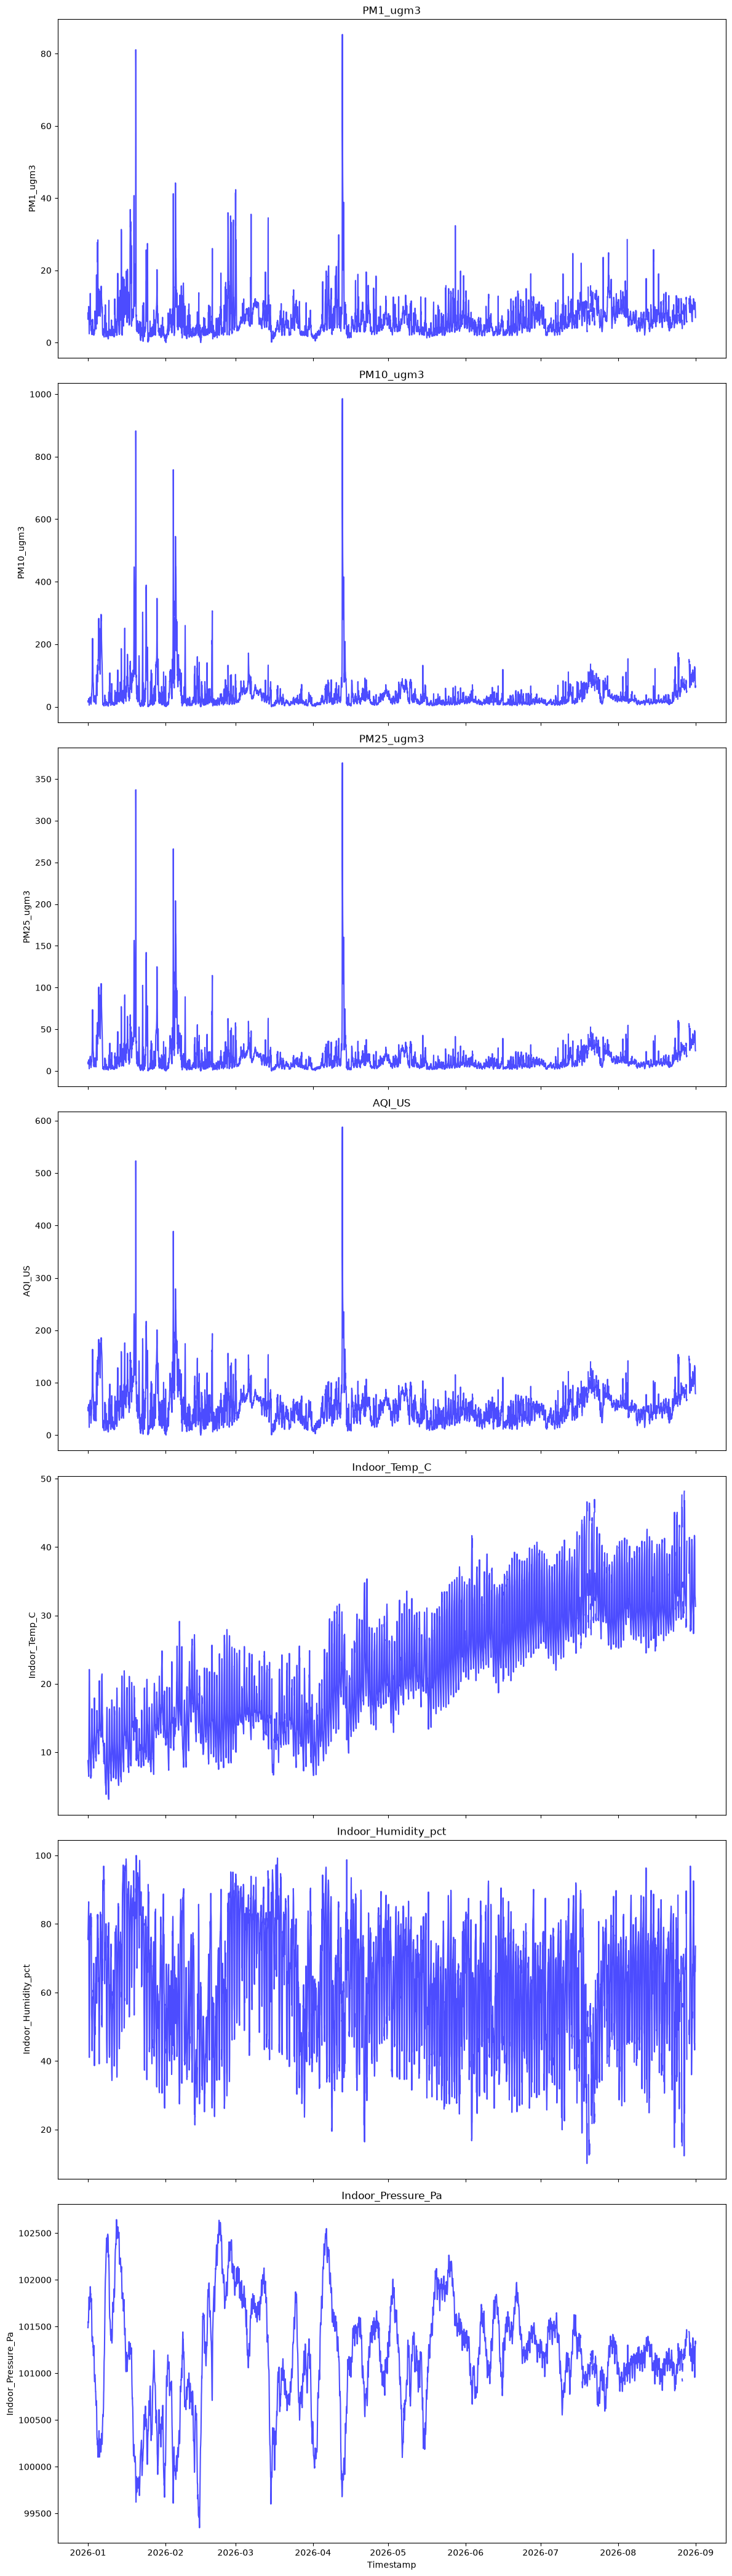

In [18]:
indoor_pm_cols = ["PM1_ugm3", "PM10_ugm3", "PM25_ugm3", "AQI_US", "Indoor_Temp_C", "Indoor_Humidity_pct", "Indoor_Pressure_Pa"]

cols_to_plot = indoor_pm_cols

fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(12, 6 * len(cols_to_plot)), sharex=True)

for ax, col in zip(axes, cols_to_plot):
    ax.plot(df["Timestamp"], df[col], label="Raw Data", color="blue", alpha=0.7)
    ax.set_title(col)
    ax.set_ylabel(col)

plt.xlabel("Timestamp")
plt.tight_layout()
plt.show()

In [19]:
# Step 1: short gaps (≤3h)
df[indoor_pm_cols] = df[indoor_pm_cols].interpolate(method="linear", limit=3)

# Step 2: anything still missing gets filled with the typical value for that same hour of day
for col in indoor_pm_cols:
    hourly_typical = df.groupby("hour")[col].transform("median")
    df[col] = df[col].fillna(hourly_typical)

print("Remaining missing after both steps:")
print(df[indoor_pm_cols].isna().sum())

Remaining missing after both steps:
PM1_ugm3               0
PM10_ugm3              0
PM25_ugm3              0
AQI_US                 0
Indoor_Temp_C          0
Indoor_Humidity_pct    0
Indoor_Pressure_Pa     0
dtype: int64


In [20]:
# Save DataFrame to Excel file
df.to_excel(f'{OUTPUT_DIR}/output3.xlsx', index=False)

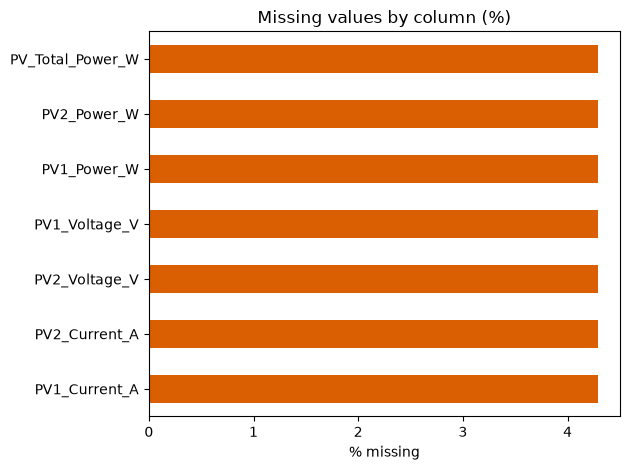

PV1_Current_A       4.286694
PV2_Current_A       4.286694
PV2_Voltage_V       4.286694
PV1_Voltage_V       4.286694
PV1_Power_W         4.286694
PV2_Power_W         4.286694
PV_Total_Power_W    4.286694
dtype: float64

In [21]:
# Check the data after this transformation
missing_pct = df.isna().mean().sort_values(ascending=False) * 100
missing_pct = missing_pct[missing_pct > 0]

if missing_pct.empty:
    print("No missing values remain.")
else:
    missing_pct.plot(kind="barh", color="#d95f02", title="Missing values by column (%)")
    plt.xlabel("% missing")
    plt.tight_layout()
    plt.show()

missing_pct

==> As we can see here, only the power data is missing

### 6.4 Handle the last missing power data

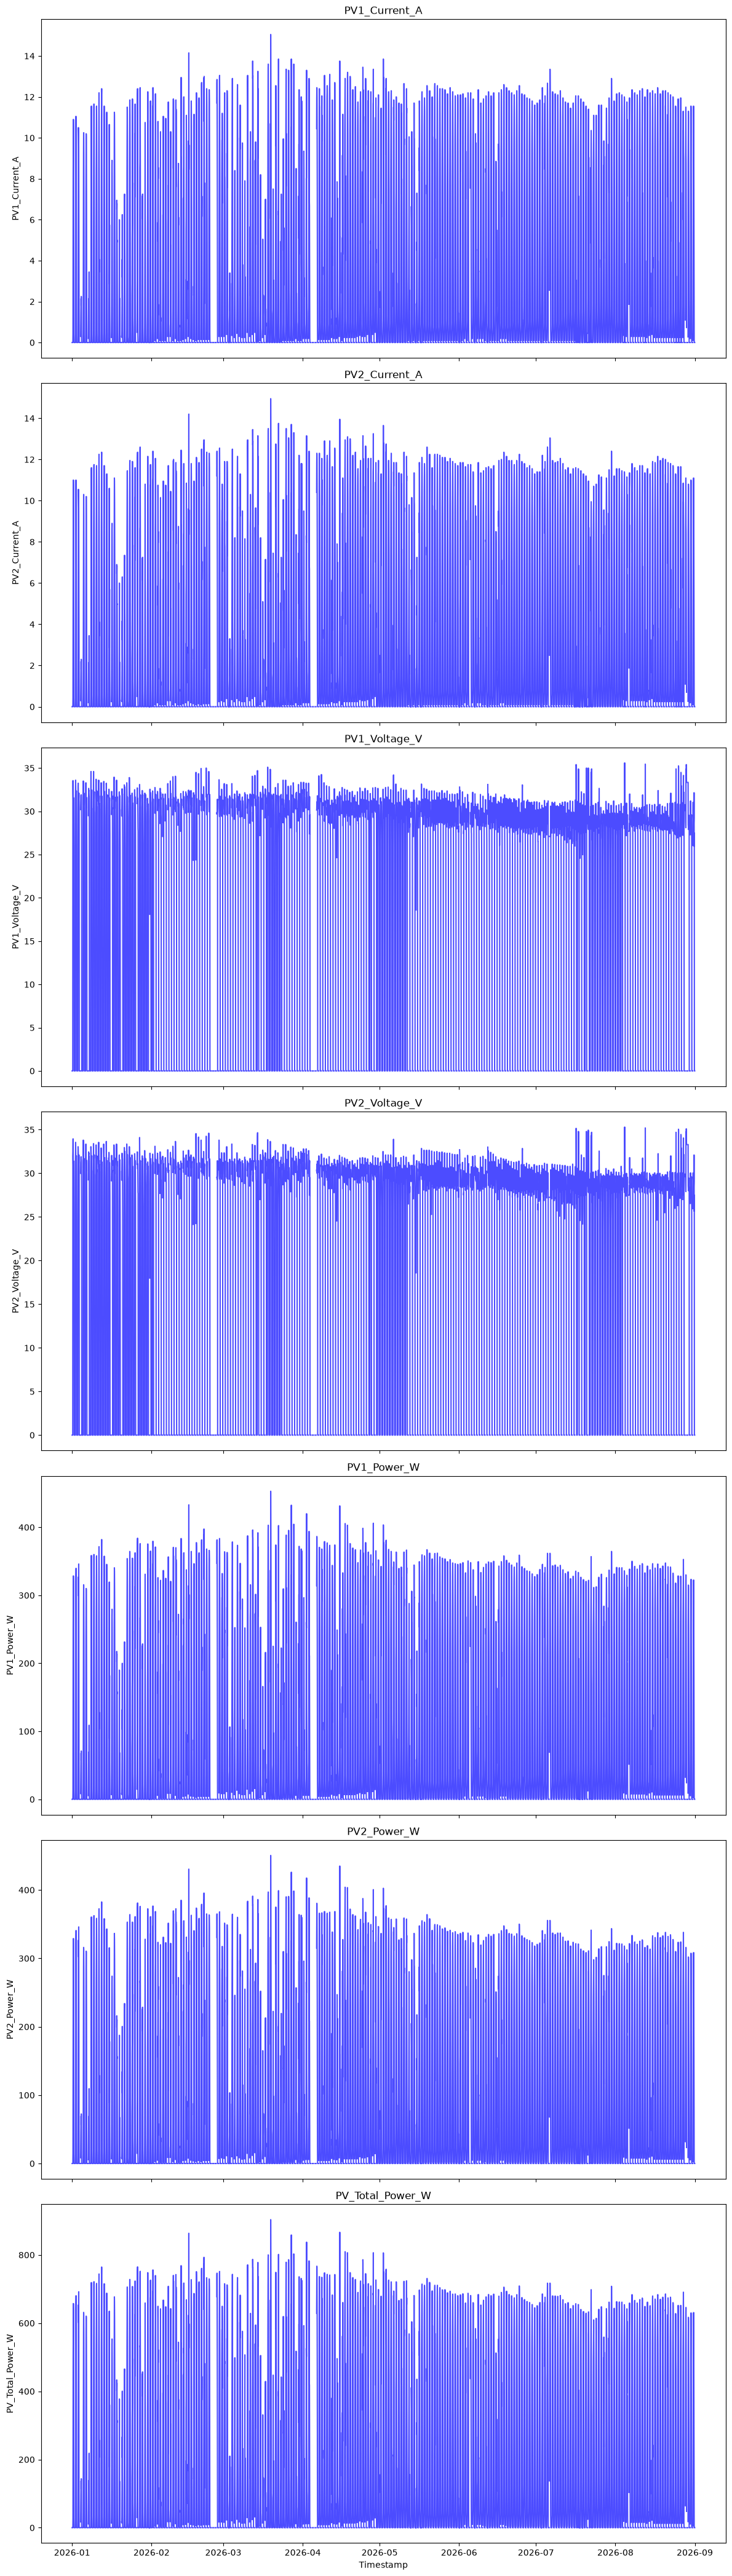

In [22]:
power_cols = ["PV1_Current_A", "PV2_Current_A", "PV1_Voltage_V", "PV2_Voltage_V", "PV1_Power_W", "PV2_Power_W", "PV_Total_Power_W"]

cols_to_plot = power_cols

fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(12, 6 * len(cols_to_plot)), sharex=True)

for ax, col in zip(axes, cols_to_plot):
    ax.plot(df["Timestamp"], df[col], label="Raw Data", color="blue", alpha=0.7)
    ax.set_title(col)
    ax.set_ylabel(col)

plt.xlabel("Timestamp")
plt.tight_layout()
plt.show()

In [23]:
# Check if there is missing solar radiation values
missing_solar_radiation = df["Solar_Radiation_Wm2"].isna().sum()
print("Number of missing solar radiation values :", missing_solar_radiation)

Number of missing solar radiation values : 0


In [24]:
# Let's use KNN for imputation with number of neighbors equal to 5

from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

cols = ["Solar_Radiation_Wm2", "Outdoor_Temp_C", "hour", "day_of_year",
        "Humidity_pct", "Wind_Speed_ms", "AQI_US", "PM1_ugm3", "PM10_ugm3", "PM25_ugm3",
        "PV1_Power_W", "PV2_Power_W", "PV_Total_Power_W",
        "PV1_Current_A", "PV2_Current_A", "PV1_Voltage_V", "PV2_Voltage_V"]

scaler = StandardScaler()
scaled = scaler.fit_transform(df[cols])          # put all columns on comparable scale

imputer = KNNImputer(n_neighbors=5, weights="distance")
filled_scaled = imputer.fit_transform(scaled)     # impute on the scaled version

filled = scaler.inverse_transform(filled_scaled)  # convert back to real units
df[cols] = filled

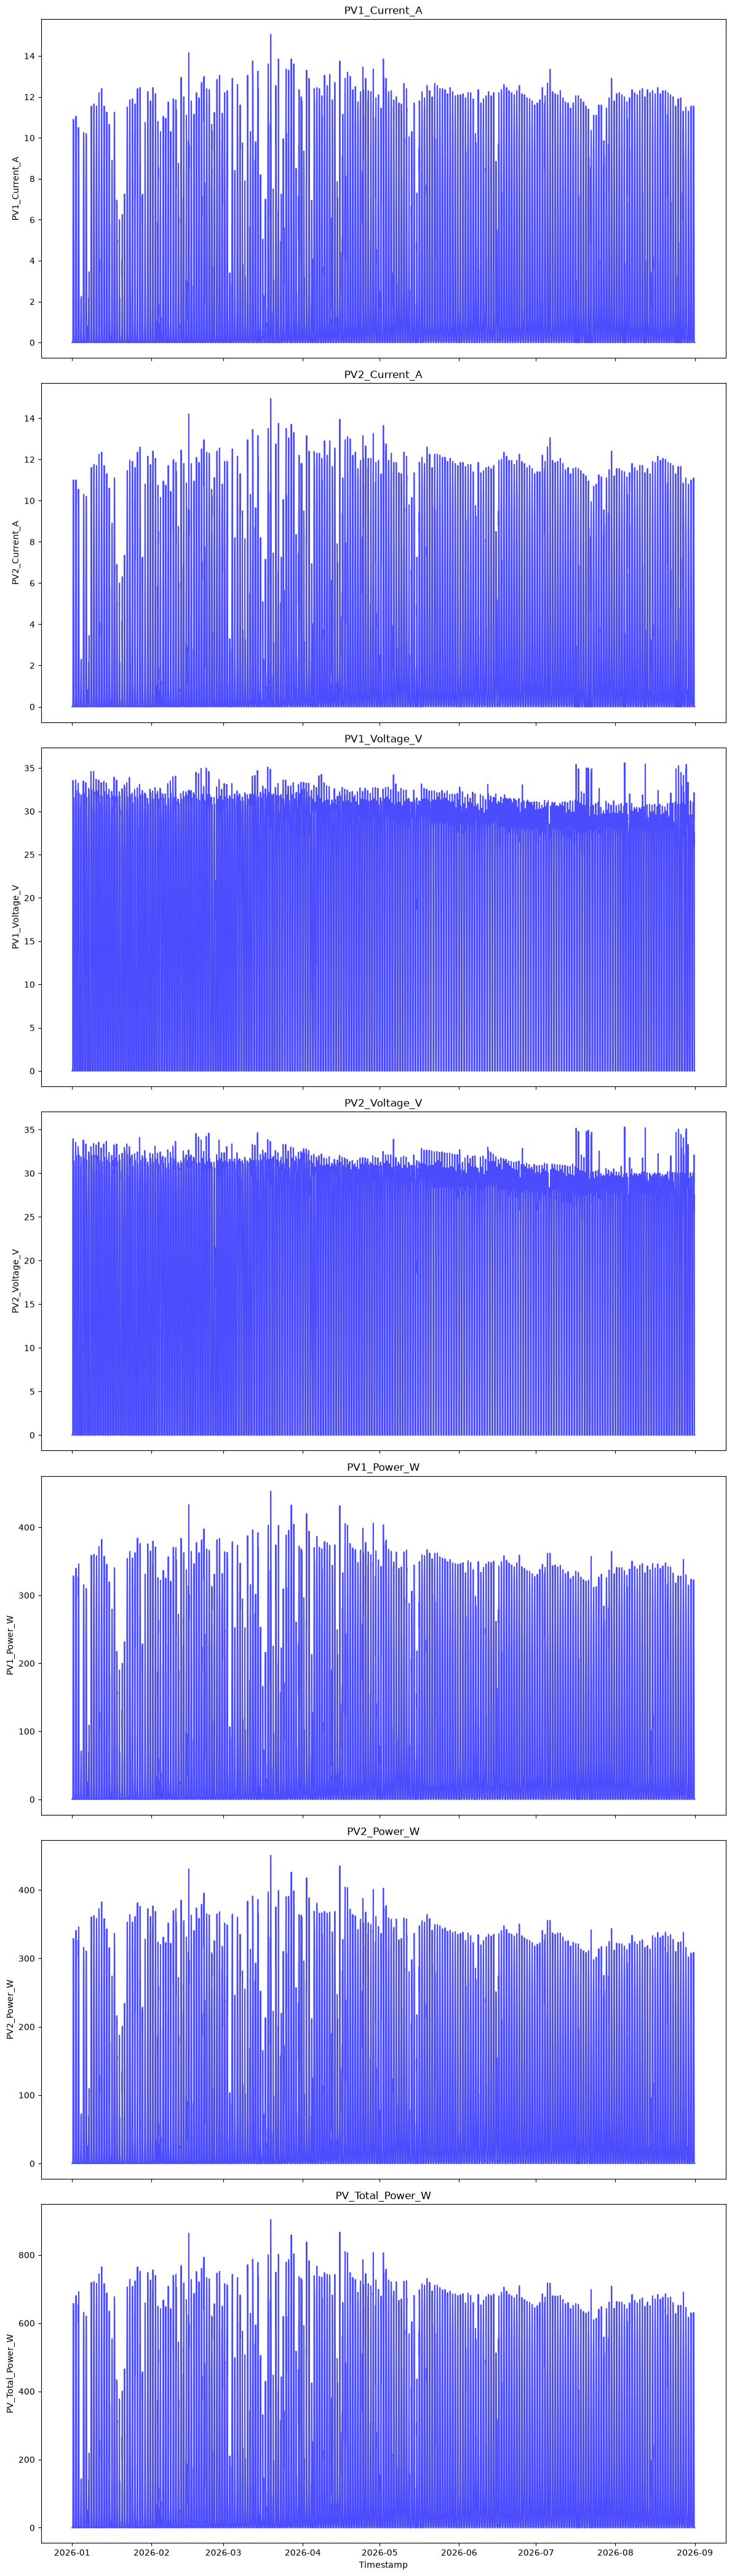

In [25]:
# Check data after handling missing data

power_cols = ["PV1_Current_A", "PV2_Current_A", "PV1_Voltage_V", "PV2_Voltage_V", "PV1_Power_W", "PV2_Power_W", "PV_Total_Power_W"]

cols_to_plot = power_cols

fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(12, 6 * len(cols_to_plot)), sharex=True)

for ax, col in zip(axes, cols_to_plot):
    ax.plot(df["Timestamp"], df[col], label="Raw Data", color="blue", alpha=0.7)
    ax.set_title(col)
    ax.set_ylabel(col)

plt.xlabel("Timestamp")
plt.tight_layout()
plt.show()

## Ready for model training

In [26]:
# Save DataFrame to Excel file
df.to_excel(f'{OUTPUT_DIR}/final.xlsx', index=False)

In [27]:
df.to_pickle(f"{OUTPUT_DIR}/checkpoint_05_final.pkl")
print("Saved checkpoint_05_final.pkl —", df.shape)
print("\nRemaining missing values:")
print(df.isna().sum()[df.isna().sum() > 0])

Saved checkpoint_05_final.pkl — (5832, 30)

Remaining missing values:
Series([], dtype: int64)
